# **Monte Carlo Pi Estimator**


## Introduction

The Monte Carlo method is a probabilistic technique that uses **random sampling** to estimate numerical quantities. 

One of the most famous applications of the Monte Carlo method is the estimation of the mathematical constant **π (pi)**.

---

# Geometric Principle

Consider a circle of radius \(r\) perfectly inscribed inside a square.

- Radius of the circle = \(r\)
- Diameter of the circle = \(2r\)
- Side length of the square = \(2r\)

### Area of the Circle

$$
A_{\text{circle}}=\pi r^2
$$


### Area of the Square

$$
A_{\text{square}}=(2r)^2=4r^2
$$


Taking the ratio of the two areas,

$$
\frac{A_{\text{circle}}}{A_{\text{square}}}
=
\frac{\pi r^2}{4r^2}
=
\frac{\pi}{4}
$$


Since ($r^2$) appears in both the numerator and denominator, it cancels out. Therefore,

$$
\boxed{\frac{\text{Area of Circle}}{\text{Area of Square}}=\frac{\pi}{4}}
$$




In [58]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.typing import NDArray
from matplotlib.patches import Circle, Rectangle

## Generating Random Points

In [59]:
rng = np.random.default_rng()
def draw_random_point(x : int , y : int , no_of_points):
    points_x = rng.uniform(low = -x , high= x , size= no_of_points)
    points_y = rng.uniform(low = -y , high= y , size= no_of_points)

    


    return points_x , points_y



## Monte Carlo Principle

Instead of computing the areas directly, we randomly generate a large number of points inside the square.

Each randomly generated point has two possibilities:

- It lies **inside the circle**.
- It lies **outside the circle**.

If the points are uniformly distributed, then the proportion of points inside the circle approaches the proportion of the circle's area inside the square.

Therefore,

$$
\frac{\text{Points Inside Circle}}
{\text{Total Points}}
\approx
\frac{\text{Area of Circle}}
{\text{Area of Square}}
$$


Substituting the area ratio,

$$
\frac{I}{N}
\approx
\frac{\pi}{4}
$$


where

- \(I\) = Number of points inside the circle
- \(N\) = Total number of randomly generated points

Multiplying both sides by 4 gives the Monte Carlo estimator of π:

$$
\boxed{\pi \approx 4\frac{I}{N}}
$$


---



# Determining Whether a Point Lies Inside the Circle

For a circle centered at the origin \((0,0)\), a point \((x,y)\) lies inside the circle if

$$
x^2+y^2\le r^2
$$


Every randomly generated point satisfying this condition is counted as an **inside point**.

---


In [63]:
def pos_of_points(coordinates_x : NDArray  , coordinates_y : NDArray , r : int ) :
    colors = np.zeros(len(coordinates_y))
    mask  = (coordinates_x **2 + coordinates_y ** 2) <= r**2


    colors = np.where(mask , 0 ,1)
    outside_count =np.count_nonzero(colors)
    return  colors ,outside_count 




## Plotting the Graph

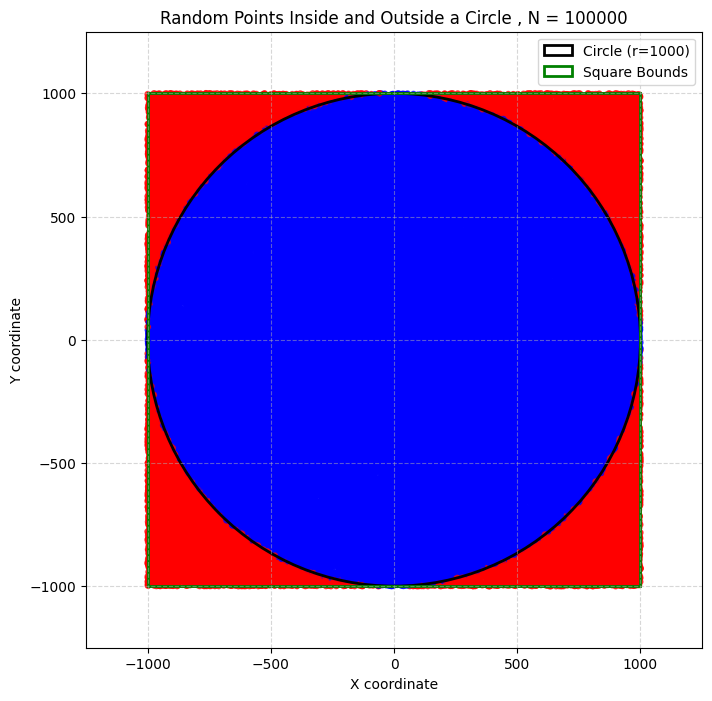

In [ ]:

n = 100000 # -> NO of Random Points
r = 20 # -> randius of Circle
x, y =draw_random_point(r ,r ,n)
colors , outside_count = pos_of_points(x, y , r )
# color -> correspond to the point the are in or outside of the Circle
# outside_count -> the number of points outside the circle 

def draw_graph(x: NDArray, y: NDArray, colors: NDArray):
    plt.figure(figsize=(8, 8))
    
    # Map 0 to 'blue' and 1 to 'red'
    color_map = np.where(colors == 0, 'blue', 'red')
    
    # Draw the scatter plot
    plt.scatter(x, y, c=color_map, s=15, alpha=0.7)
    
    # Draw the boundary circle (radius 20)
    circle = Circle((0, 0), r, color='black', fill=False, linewidth=2, label=f'Circle (r={r})')
    plt.gca().add_patch(circle)
    
    square = Rectangle((-r, -r), 2*r, 2*r, color='green', fill=False, linewidth=2, label='Square Bounds')
    plt.gca().add_patch(square)
    
    # Formatting the plot
    percent = r/4
    plt.xlim(-r-percent, r+percent)
    plt.ylim(-r-percent, r+percent)
    
    # Ensure the aspect ratio is 1:1 so the circle isn't stretched into an oval
    plt.gca().set_aspect('equal') 
    
    plt.title(f"Random Points Inside and Outside a Circle , N = {n}")
    plt.xlabel("X coordinate")
    plt.ylabel("Y coordinate")
    plt.legend(loc="upper right")
    
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

draw_graph(x, y, colors)



# Why Does the Estimate Improve?

The Monte Carlo method is based on the **Law of Large Numbers**.

As the number of random samples increases, the observed proportion of points inside the circle becomes closer to the true area ratio.

Mathematically,

$$
\lim_{N\rightarrow\infty}\frac{I}{N}
=
\frac{\pi}{4}
$$


Therefore,

$$
\lim_{N\rightarrow\infty}
4\frac{I}{N}
=
\pi
$$


This means that increasing the number of random points makes the estimate converge toward the true value of π.

---


In [67]:
dot_inside_circle = n-outside_count 
total_dots = n
estimated_pi  = 4*(dot_inside_circle/total_dots)
print(f"Pi ~ {estimated_pi}")

Pi ~ 3.13916



# Error in Monte Carlo Estimation

Unlike many numerical methods, the Monte Carlo method converges relatively slowly.

The estimation error decreases approximately as

$$
\boxed{\text{Error}\propto\frac{1}{\sqrt{N}}}
$$


where \(N\) is the number of random samples.

This relationship means:

- Doubling the number of points **does not** halve the error.
- To reduce the error by a factor of **10**, approximately **100 times more samples** are required.

For example,

| Number of Points (\(N\)) | Relative Error Scale |
|--------------------------:|---------------------:|
| \($10^3$\) | \($\frac{1}{31.6}$\) |
| \($10^4$\) | \($\frac{1}{100}$\) |
| \($10^5$\) | \($\frac{1}{316}$\) |
| \($10^6$\) | \($\frac{1}{1000}$\) |
| \($10^8$\) | \($\frac{1}{10000}$\) |

Thus, increasing the number of random samples produces increasingly accurate estimates, although the improvement is gradual because the error decreases proportionally to \($1/\sqrt{N}$\).



In [ ]:
Error = 1 / np.sqrt(n)
print(f"Error = {Error}")
      

0.003162277660168379


* This mean estimated Pi value and error should equal to Pi

In [68]:
print(f"PI = estmated pi + error = {estimated_pi + Error}")


PI = estmated pi + error = 3.1423222776601683


### In Conclusion   


The Monte Carlo method provides a simple and intuitive way to estimate the value of **π** using random sampling. 

$$
\pi \approx 4\frac{I}{N},
$$

where \(I\) is the number of points inside the circle and \(N\) is the total number of random points.

As the number of samples increases, the estimate becomes more accurate due to the **Law of Large Numbers**, causing the estimated value to converge toward the true value of π. However, the convergence is relatively slow, with the estimation error decreasing approximately as

$$
\text{Error} \propto \frac{1}{\sqrt{N}}.$$

This means that achieving significantly higher accuracy requires a much larger number of random samples. 